Dataset Shape: (34500, 17)


,price,discount,quantity,order_date,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,2024-09-13 13:39:17.843478,4.814203,170.008494,6.152120,28.116505,43.474377
min,1.010000,0.000000,1.000000,2023-09-12 00:00:00,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,2024-03-14 00:00:00,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,2024-09-16 00:00:00,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,2025-03-17 00:00:00,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,2025-09-11 00:00:00,13.000000,12931.800000,15.650000,1536.170000,69.000000
std,195.620477,0.069894,0.932270,NaN,1.242141,357.503014,2.389539,53.352947,14.980682


Categories: <StringArray>
['Home', 'Grocery', 'Electronics', 'Beauty', 'Fashion', 'Toys', 'Sports']
Length: 7, dtype: str
Regions: <StringArray>
['West', 'South', 'North', 'East', 'Central']
Length: 5, dtype: str
Payment Methods: <StringArray>
['Credit Card', 'UPI', 'COD', 'PayPal', 'Debit Card', 'Wallet']
Length: 6, dtype: str
Return Status: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Missing values: 0
Duplicate rows: 0
Negative prices: 0
Invalid discounts: 0
Invalid quantities: 0
Invalid delivery days: 0
Invalid customer ages: 0


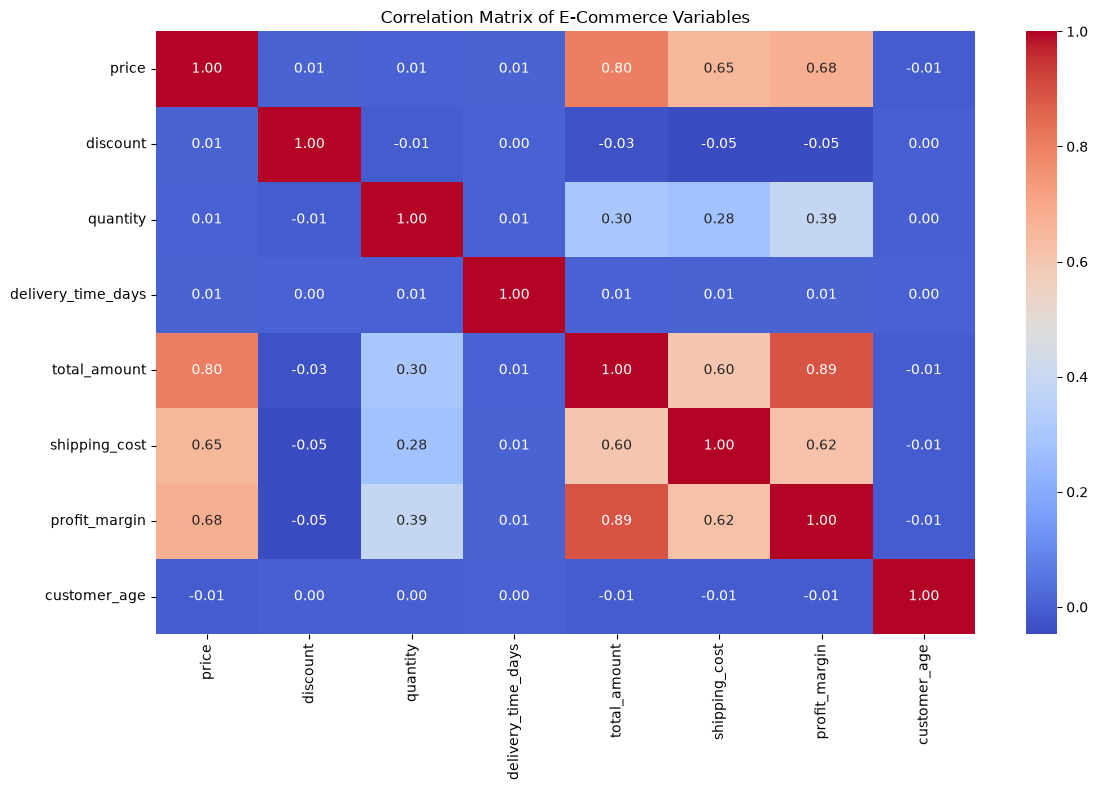

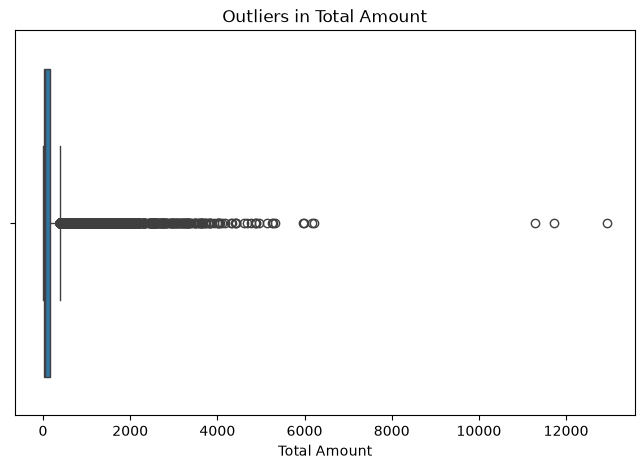

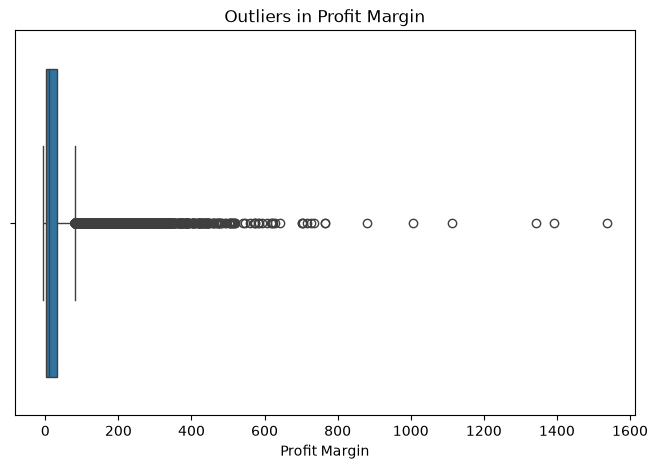

Total Sales: 5865293.05
Average Order Value: 170.00849420289853
Total Quantity Sold: 51430
Average Profit Margin: 28.11650463768116
Return Rate: 5.515942028985507 %
Sales by Category:
category
Electronics    3319206.50
Home           1077681.52
Sports          629825.54
Fashion         471545.80
Beauty          153019.38
Toys            132013.80
Grocery          82000.51
Name: total_amount, dtype: float64
Profit Margin by Category:
category
Electronics    55.723587
Home           47.864717
Sports         38.485114
Fashion        20.597162
Beauty         11.990395
Toys            7.927773
Grocery        -2.264160
Name: profit_margin, dtype: float64
Sales by Region:
region
South      1298096.07
North      1264008.35
West       1186350.50
East       1176334.75
Central     940503.38
Name: total_amount, dtype: float64
Profit Margin by Region:
region
West       28.993204
East       28.249600
Central    28.058184
South      27.832433
North      27.534810
Name: profit_margin, dtype: float64
M

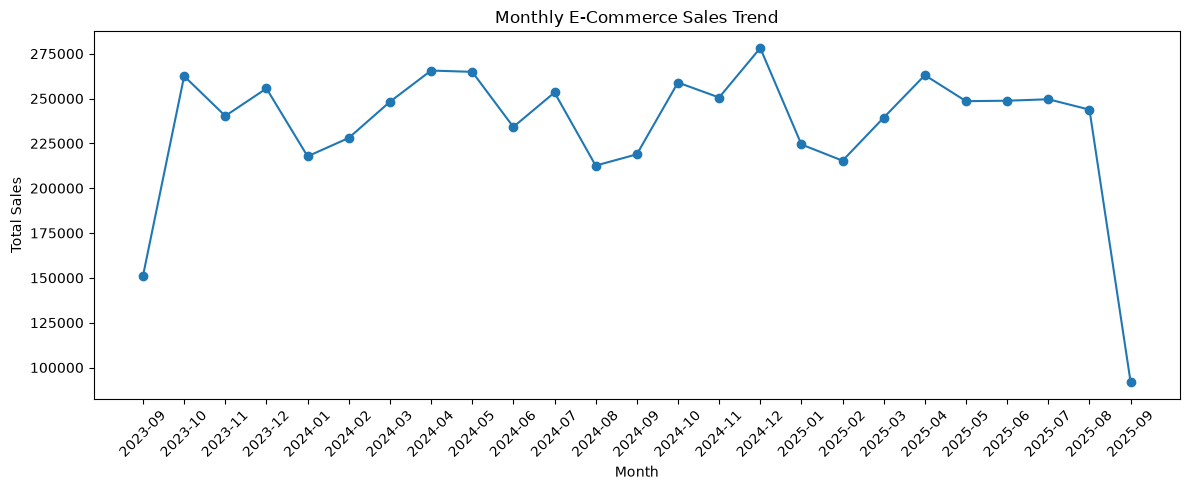

Return Rate by Category:
category
Fashion        8.282699
Electronics    7.297735
Home           5.649718
Toys           4.944667
Sports         4.938864
Beauty         3.777724
Grocery        1.306062
Name: returned, dtype: float64
Return Rate by Region:
region
East       5.909618
South      5.683017
West       5.449471
North      5.361859
Central    5.095881
Name: returned, dtype: float64
Average Customer Age: 43.474376811594205
Minimum Customer Age: 18
Maximum Customer Age: 69
Sales by Gender:
customer_gender
Female    2853296.96
Male      2793055.33
Other      218940.76
Name: total_amount, dtype: float64


In [30]:
# Load and inspect the data
print("Dataset Shape:", df.shape)
display(df.describe())

# Check the main categories
print("Categories:", df["category"].unique())
print("Regions:", df["region"].unique())
print("Payment Methods:", df["payment_method"].unique())
print("Return Status:", df["returned"].unique())

# Quick data quality check
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Check for invalid values
print("Negative prices:", (df["price"] < 0).sum())
print("Invalid discounts:", ((df["discount"] < 0) | (df["discount"] > 1)).sum())
print("Invalid quantities:", (df["quantity"] <= 0).sum())
print("Invalid delivery days:", (df["delivery_time_days"] <= 0).sum())
print("Invalid customer ages:", ((df["customer_age"] < 18) | (df["customer_age"] > 100)).sum())

# Correlation
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of E-Commerce Variables")
plt.tight_layout()
plt.show()

# Check outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["total_amount"])
plt.title("Outliers in Total Amount")
plt.xlabel("Total Amount")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["profit_margin"])
plt.title("Outliers in Profit Margin")
plt.xlabel("Profit Margin")
plt.show()

# Basic business numbers
print("Total Sales:", df["total_amount"].sum())
print("Average Order Value:", df["total_amount"].mean())
print("Total Quantity Sold:", df["quantity"].sum())
print("Average Profit Margin:", df["profit_margin"].mean())

return_rate = (df["returned"] == "Yes").mean() * 100
print("Return Rate:", return_rate, "%")

# Category analysis
category_sales = df.groupby("category")["total_amount"].sum().sort_values(ascending=False)
category_profit = df.groupby("category")["profit_margin"].mean().sort_values(ascending=False)

print("Sales by Category:")
print(category_sales)

print("Profit Margin by Category:")
print(category_profit)

# Region analysis
region_sales = df.groupby("region")["total_amount"].sum().sort_values(ascending=False)
region_profit = df.groupby("region")["profit_margin"].mean().sort_values(ascending=False)

print("Sales by Region:")
print(region_sales)

print("Profit Margin by Region:")
print(region_profit)

# Monthly sales trend
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["total_amount"].sum()

print("Monthly Sales:")
print(monthly_sales)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly E-Commerce Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Return analysis
return_by_category = df.groupby("category")["returned"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)

return_by_region = df.groupby("region")["returned"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)

print("Return Rate by Category:")
print(return_by_category)

print("Return Rate by Region:")
print(return_by_region)

# Customer analysis
print("Average Customer Age:", df["customer_age"].mean())
print("Minimum Customer Age:", df["customer_age"].min())
print("Maximum Customer Age:", df["customer_age"].max())

gender_sales = df.groupby("customer_gender")["total_amount"].sum().sort_values(ascending=False)

print("Sales by Gender:")
print(gender_sales)